.1 Load & Inspect 

In [1]:
import pandas as pd

df = pd.read_csv("house_prices.csv")

df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [2]:
df.shape

(187531, 21)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

In [4]:
df.describe()

,Index,Price (in rupees),Dimensions,Plot Area
count,187531.000000,1.698660e+05,0.0,0.0
mean,93765.000000,7.583772e+03,NaN,NaN
std,54135.681003,2.724171e+04,NaN,NaN
min,0.000000,0.000000e+00,NaN,NaN
25%,46882.500000,4.297000e+03,NaN,NaN
50%,93765.000000,6.034000e+03,NaN,NaN
75%,140647.500000,9.450000e+03,NaN,NaN
max,187530.000000,6.700000e+06,NaN,NaN


In [5]:
df.isna().mean().sort_values(ascending=False)

Plot Area            1.000000
Dimensions           1.000000
Society              0.584853
Super Area           0.574225
Car Parking          0.551146
overlooking          0.434254
Carpet Area          0.430185
facing               0.374514
Ownership            0.349366
Balcony              0.260944
Price (in rupees)    0.094198
Floor                0.037738
Description          0.016120
Furnishing           0.015448
Bathroom             0.004415
Status               0.003279
Transaction          0.000443
Amount(in rupees)    0.000000
Title                0.000000
Index                0.000000
location             0.000000
dtype: float64

In [6]:

df.isnull().sum()

Index                     0
Title                     0
Description            3023
Amount(in rupees)         0
Price (in rupees)     17665
location                  0
Carpet Area           80673
Status                  615
Floor                  7077
Transaction              83
Furnishing             2897
facing                70233
overlooking           81436
Society              109678
Bathroom                828
Balcony               48935
Car Parking          103357
Ownership             65517
Super Area           107685
Dimensions           187531
Plot Area            187531
dtype: int64

 Dataset summary:

 number of rows,columns ....(187531, 21)
 
 Numeric columns.... Index, Price (in rupees), Dimensions, Plot Area

 Text columns....... Title, Description, Amount(in rupees), location, Carpet Area, Status, Floor ,Transaction, Furnishing, facing, overlooking, Society, Bathroom, Balcony, Car Parking, Ownership, Super Area
   
  columns Which have the most missing values...... Plot Area ,Dimensions

.2 Cleaning & Feature Engineering 

In [7]:
def parse_amount(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5
        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7
        return float(x.replace(",", ""))
    except ValueError:
        return None

df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)

df = df.dropna(subset=["price_clean"])

In [8]:
def parse_area(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "sqft" in x:
            return float(x.replace("sqft", "").strip())
        if "sqm" in x:
            return float(x.replace("sqm", "").strip()) * 10.764
        if "acre" in x:
            return float(x.replace("acre", "").strip()) * 43560
        if "hectare" in x:
            return float(x.replace("hectare", "").strip()) * 107639
        return float(x.replace(",", ""))
    except ValueError:
        return None

df["Carpet_Area_clean"] = df["Carpet Area"].apply(parse_area)
df = df.dropna(subset=["Carpet_Area_clean"])
df = df[(df["Carpet_Area_clean"] > 100) & (df["Carpet_Area_clean"] < 10000)]

In [9]:
df["clean_floor"]= df['Floor'].replace({'Ground': 0, 'Basement': -1})
df["clean_floor"]=(df["clean_floor"].astype(str).str.extract('(-?\d+)').astype(float))
df["clean_floor"] = df["clean_floor"].fillna(df["clean_floor"].median()).astype(int)



<>:2: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:2: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\HP\AppData\Local\Temp\ipykernel_3744\3362092804.py:2: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  df["clean_floor"]=(df["clean_floor"].astype(str).str.extract('(-?\d+)').astype(float))


In [10]:
df["Bathrooms_clean"] = pd.to_numeric(df["Bathroom"], errors="coerce")
df["Bathrooms_clean"] = df["Bathrooms_clean"].fillna(df["Bathrooms_clean"].median()).astype(int)

df["Balcony_clean"] = pd.to_numeric(df["Balcony"], errors="coerce")
df["Balcony_clean"] = df["Balcony_clean"].fillna(df["Balcony_clean"].median()).astype(int)

df["clean_Car_Parking"] = (df["Car Parking"].astype(str).str.extract("(\d+)").astype(float))
df["clean_Car_Parking"] = df["clean_Car_Parking"].fillna(0).astype(int)



<>:7: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:7: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\HP\AppData\Local\Temp\ipykernel_3744\4232002535.py:7: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  df["clean_Car_Parking"] = (df["Car Parking"].astype(str).str.extract("(\d+)").astype(float))


In [11]:
top_50_locations = df["location"].value_counts().head(50).index

def group_locations(x):
    if x in top_50_locations :
        return x
    else:
        return "other" 

df["location_grouped"]=df["location"].apply(group_locations)


In [12]:
cols_to_drop = ["Super Area","Dimensions","Plot Area","Society","overlooking","facing","Ownership","Price (in rupees)", "Carpet Area" ,"Floor", "Bathroom", "Balcony",  
    "Car Parking", "Index", "Title", "Description", "Amount(in rupees)","location"]
df.drop(columns=[col for col in cols_to_drop if col in df.columns], inplace=True)




In [13]:
price_per_sqft = df["price_clean"] / df["Carpet_Area_clean"]

low_limit = price_per_sqft.quantile(0.01)
high_limit = price_per_sqft.quantile(0.99)

df = df[(price_per_sqft >= low_limit) & (price_per_sqft <= high_limit)]



Price per square foot (price_per_sqft) was calculated as a temporary benchmark to filter out data entry errors and extreme anomalies between the 1st and 99th percentiles, mitigating distortion before model training without inducing data leakage

In [14]:
df.isnull().sum()

Status               70
Transaction          61
Furnishing           25
price_clean           0
Carpet_Area_clean     0
clean_floor           0
Bathrooms_clean       0
Balcony_clean         0
clean_Car_Parking     0
location_grouped      0
dtype: int64

In [15]:
df.info()

<class 'pandas.DataFrame'>
Index: 93983 entries, 0 to 187528
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Status             93913 non-null  str    
 1   Transaction        93922 non-null  str    
 2   Furnishing         93958 non-null  str    
 3   price_clean        93983 non-null  float64
 4   Carpet_Area_clean  93983 non-null  float64
 5   clean_floor        93983 non-null  int64  
 6   Bathrooms_clean    93983 non-null  int64  
 7   Balcony_clean      93983 non-null  int64  
 8   clean_Car_Parking  93983 non-null  int64  
 9   location_grouped   93983 non-null  str    
dtypes: float64(2), int64(4), str(4)
memory usage: 7.9 MB


.3 Exploratory Data Analysis (EDA) 

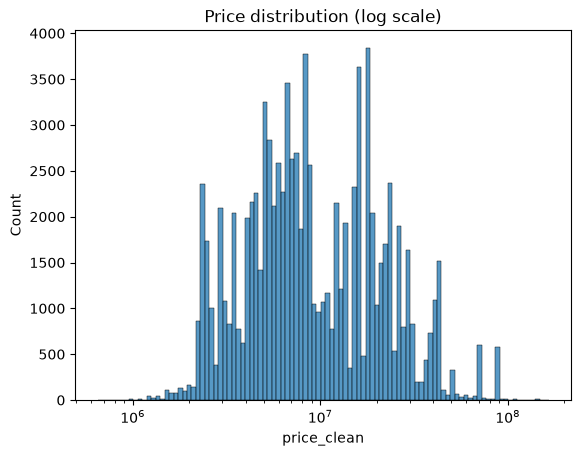

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df["price_clean"], log_scale=True)
plt.title("Price distribution (log scale)")
plt.show()

Observation on Price Distribution:


Most properties are concentrated in the mid-range price segment, with only a small number of very cheap homes and a small number of extremely expensive luxury homes.

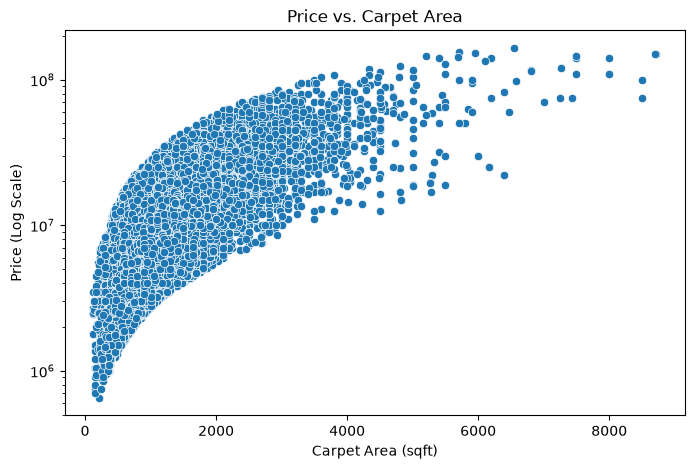

In [17]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="Carpet_Area_clean", y="price_clean")

plt.yscale("log")
plt.title("Price vs. Carpet Area")
plt.xlabel("Carpet Area (sqft)")
plt.ylabel("Price (Log Scale)")
plt.show()

Observation on Price vs. Carpet Area:

A clear positive correlation exists between carpet area and price; larger properties generally cost more.

The vast majority of listings are concentrated between 500 and 2,500 sqft.

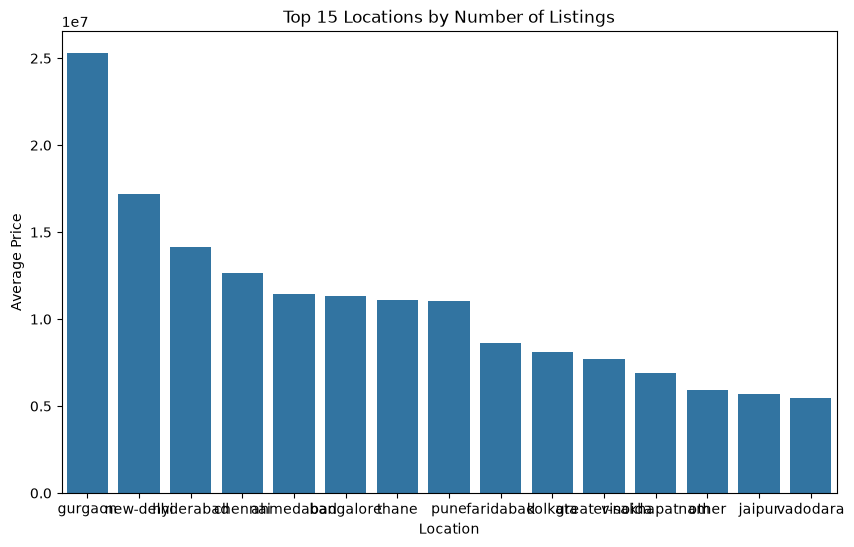

In [18]:
top_15_locations = df["location_grouped"].value_counts().head(15).index
avg_prices = df[df["location_grouped"].isin(top_15_locations)].groupby("location_grouped")["price_clean"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
plt.title("Top 15 Locations by Number of Listings")
sns.barplot(x=avg_prices.index, y=avg_prices.values)
plt.xlabel("Location")
plt.ylabel("Average Price")
plt.show()

Observation on Average Price by Top 15 Locations:

Mumbai and Gurgaon record the highest average prices by a wide margin.

Property prices vary significantly by city, dropping to their lowest in Jaipur and Visakhapatnam.

Text(0, 0.5, 'Price ( Log Scale)')

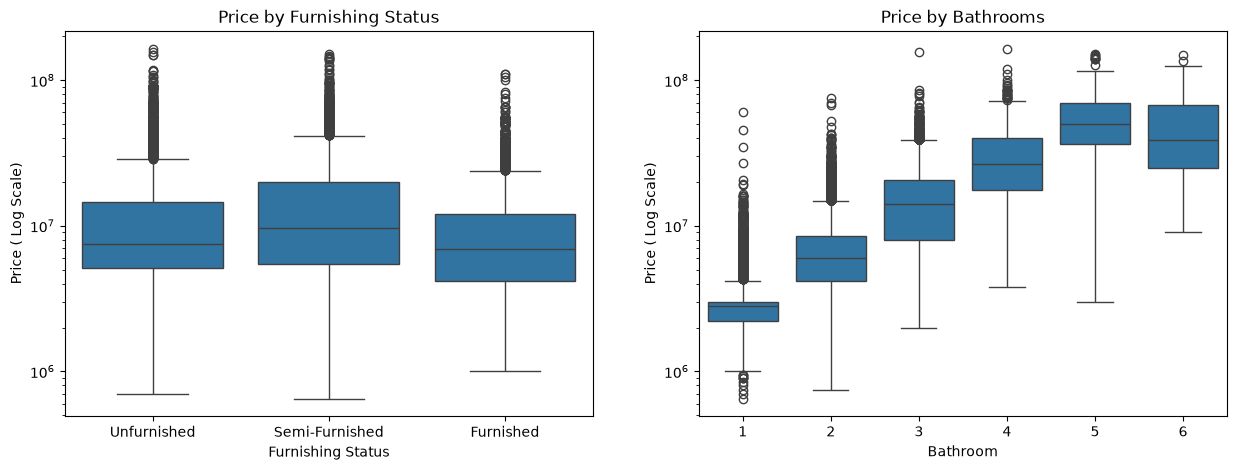

In [19]:

df = df.dropna(subset=["Furnishing"])
df = df[df["Bathrooms_clean"] <= 6]

fig, axis = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=df, x="Furnishing", y="price_clean", ax=axis[0])

axis[0].set_yscale("log")
axis[0].set_title("Price by Furnishing Status")
axis[0].set_xlabel("Furnishing Status")
axis[0].set_ylabel("Price ( Log Scale)")

sns.boxplot(data=df, x="Bathrooms_clean", y="price_clean", ax=axis[1])

axis[1].set_yscale("log")
axis[1].set_title("Price by Bathrooms")
axis[1].set_xlabel("Bathroom")
axis[1].set_ylabel("Price ( Log Scale)")


Observations on Price by Bathroom:

Property price scales up consistently with the number of bathrooms, showing a strong positive relationship.


Observations on Price by Furnishing:

Median prices are very similar across furnishing statuses, indicating furnishing alone is not a primary driver of price compared to unit size or layout.


.4 Build a Pipeline & Train

In [20]:
from sklearn.model_selection import train_test_split 
from sklearn.compose import ColumnTransformer 
from sklearn.pipeline import Pipeline 
from sklearn.impute import SimpleImputer 
from sklearn.preprocessing import OneHotEncoder, StandardScaler 
from sklearn.ensemble import RandomForestRegressor 
from sklearn.linear_model import LinearRegression 
import numpy as np
from sklearn.compose import TransformedTargetRegressor

In [21]:
numeric_features = ["Carpet_Area_clean","clean_floor","Bathrooms_clean","Balcony_clean","clean_Car_Parking"]
categorical_features = ["location_grouped", "Furnishing", "Transaction", "Status"]


preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                [
                    ("impute", SimpleImputer(strategy="median")),
                    ("scale", StandardScaler()),
                ]
            ),
            numeric_features,
        ),
        (
            "cat",
            Pipeline(
                [
                    ("impute", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            categorical_features,
        ),
    ]
)


X = df[numeric_features + categorical_features]
y = df["price_clean"]



X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

y_train_log = np.log1p(y_train)

linear_model = Pipeline(
    [("preprocessor", preprocessor), ("model", LinearRegression())]
)
linear_model.fit(X_train, y_train_log)
linear_pred_log = linear_model.predict(X_test)
linear_pred = np.expm1(linear_pred_log)



rf_base = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(n_estimators=100, random_state=42, max_depth=15)),
    ]
)
rf_model = TransformedTargetRegressor(
    regressor=rf_base,
    func=np.log1p,
    inverse_func=np.expm1
)

rf_model.fit(X_train, y_train)       
rf_pred = rf_model.predict(X_test)   


.5 Evaluate 

In [22]:
from sklearn.metrics import mean_absolute_error,root_mean_squared_error,r2_score

linear_MAE=mean_absolute_error(y_test,linear_pred)
linear_RMSE=root_mean_squared_error(y_test,linear_pred)
linear_R2=r2_score(y_test,linear_pred)

rf_MAE=mean_absolute_error(y_test,rf_pred)
rf_RMSE=root_mean_squared_error(y_test,rf_pred)
rf_R2=r2_score(y_test,rf_pred)

results = pd.DataFrame({"model":["LinearRegression","RandomForestRegressor"],
                        "MAE":[linear_MAE,rf_MAE],
                        "RMSE":[linear_RMSE,rf_RMSE],
                        "R2" :[linear_R2,rf_R2]

                        }
                       )
display(results)

,model,MAE,RMSE,R2
0,LinearRegression,4.151531e+06,1.003407e+07,0.402440
1,RandomForestRegressor,9.993352e+05,2.935158e+06,0.948868


Model Comparison:

The Random Forest Regressor performed better than Linear Regression on the test set. It achieved lower MAE and RMSE values, which means its prediction errors were smaller. It also achieved a higher R² score of 0.9489 compared with 0.4024 for Linear Regression. Therefore, Random Forest Regressor was selected as the final model because it provided better predictive performance on the test data.

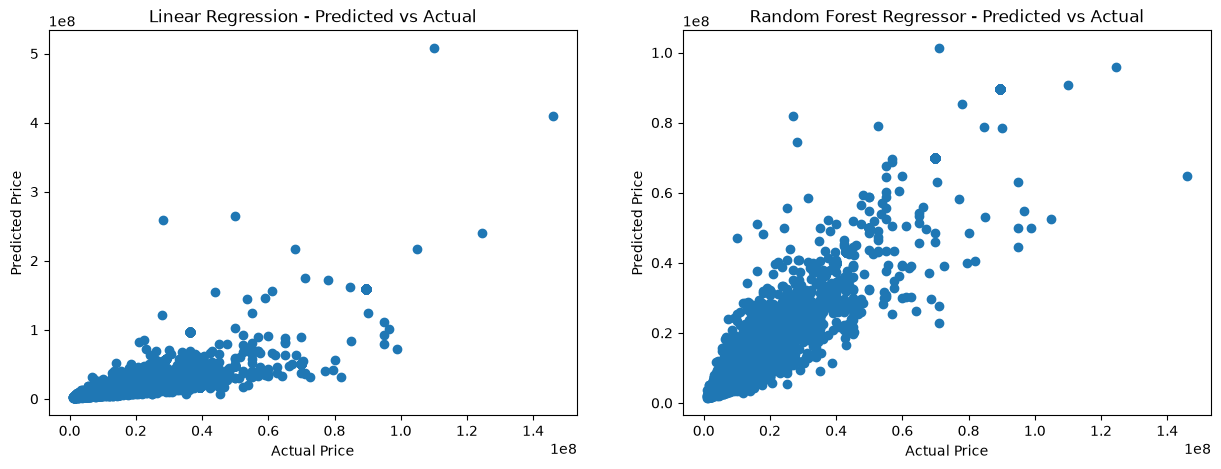

In [23]:
fig, axis = plt.subplots(1, 2, figsize=(15, 5))
axis[0].scatter(y_test,linear_pred)
axis[0].set_xlabel("Actual Price")
axis[0].set_ylabel("Predicted Price")
axis[0].set_title("Linear Regression - Predicted vs Actual")


axis[1].scatter(y_test,rf_pred)
axis[1].set_xlabel("Actual Price")
axis[1].set_ylabel("Predicted Price")
axis[1].set_title("Random Forest Regressor - Predicted vs Actual")
plt.show()

In [24]:
import joblib

model_filename = "house_price_pipeline.pkl"
joblib.dump(rf_model, model_filename)

print(f"Model successfully saved as: {model_filename}")

Model successfully saved as: house_price_pipeline.pkl


In [25]:
import json 
json.dump(sorted(df["location_grouped"].unique().tolist()), open("locations.json", "w"))